# 任务A：二分类（灰色 Grey vs 黄色 Yellow）

In [1]:
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models
from matplotlib import pyplot as plt
import torchvision.transforms as T
import os
from PIL import Image
import time
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

# 配置信息
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"训练设备: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

训练设备: cuda:0
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 可视化函数

In [2]:
def plot_curves(loss_data, acc_data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(loss_data, 'b-', label='Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(acc_data, 'g-', label='Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

In [3]:
def plot_image(img, label, name):
    fig = plt.figure(figsize=(8, 4))
    img = img.detach().numpy()
    labels = ['Grey', 'Yellow']
    for i in range(min(4, len(img))):
        plt.subplot(1, 4, i + 1)
        plt.imshow(img[i].transpose(1,2,0))
        plt.title(f"{name}: {labels[label[i].item()]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## 数据集定义

In [4]:
class MyDataset(Dataset):
    def __init__(self, flag='train'):
        self.flag = flag
        self.Animedata_path = []
        
        # 使用data目录，二分类：Grey和Yellow
        if flag == 'train':
            base = "./data/train"
        else:
            base = "./data/test"
        
        # Grey(0)和Yellow(1)二分类
        for i in os.listdir(os.path.join(base, "grey")):
            self.Animedata_path.append((os.path.join(base, "grey", i), 0))
        for i in os.listdir(os.path.join(base, "yellow")):
            self.Animedata_path.append((os.path.join(base, "yellow", i), 1))
        
        # 数据增强
        if flag == 'train':
            self.transforms = T.Compose([
                T.Resize((224, 224)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(15),
                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
        else:
            self.transforms = T.Compose([
                T.Resize((224, 224)),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
            
    def __getitem__(self, index):
        path, label = self.Animedata_path[index]
        image = Image.open(path)
        image = self.transforms(image)
        return image, label
    
    def __len__(self):
        return len(self.Animedata_path)

## 数据加载

训练集样本数: 30291
测试集样本数: 7514
Batch size: 64


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


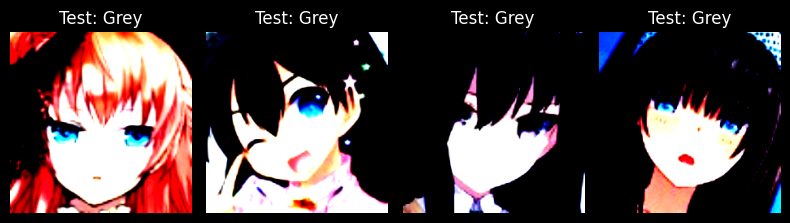

In [5]:
batch_size = 64

train_loader = DataLoader(
    MyDataset(flag='train'),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
test_loader = DataLoader(
    MyDataset(flag='test'),
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"训练集样本数: {len(train_loader.dataset)}")
print(f"测试集样本数: {len(test_loader.dataset)}")
print(f"Batch size: {batch_size}")

# 显示样本图片
x, y = next(iter(test_loader))
plot_image(x, y, "Test")

## 模型定义 - 使用预训练ResNet18

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN, self).__init__()
        
        # 卷积层
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)  # 224->112
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 112->56
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 56->28
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)  # 28->14
        
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(2, 2)  # 14->7
        
        # 全局平均池化
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # 全连接层
        self.fc1 = nn.Linear(512, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # 卷积块
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.pool5(F.relu(self.bn5(self.conv5(x))))
        
        # 全局平均池化
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        
        # 全连接层
        x = self.dropout(F.relu(self.bn_fc1(self.fc1(x))))
        x = self.fc2(x)
        
        return x

net = CNN(num_classes=2).to(device)
print(f"模型结构: CNN + GlobalAvgPool")
print(f"模型参数量: {sum(p.numel() for p in net.parameters()):,}")


模型结构: CNN + GlobalAvgPool
模型参数量: 1,702,914


## 优化器与损失函数

In [7]:
optimizer = optim.AdamW(net.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss()

print("优化器: AdamW")
print("损失函数: CrossEntropyLoss")
print("学习率调度: StepLR (每5轮衰减50%)")


优化器: AdamW
损失函数: CrossEntropyLoss
学习率调度: StepLR (每5轮衰减50%)


## 训练

In [8]:
from tqdm import tqdm

train_loss = []
train_acc = []
val_acc = []
best_acc = 0.0
num_epochs = 20

start_time = time.time()

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = net(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
        
        pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{100.*correct/total:.1f}%")
    
    pbar.close()
    scheduler.step()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)
    
    # 验证
    net.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = net(x)
            pred = outputs.argmax(dim=1)
            val_correct += pred.eq(y).sum().item()
            val_total += y.size(0)
    
    val_acc_epoch = 100. * val_correct / val_total
    val_acc.append(val_acc_epoch)
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Train: {epoch_acc:.2f}% | Val: {val_acc_epoch:.2f}% | Time: {elapsed:.1f}s")
    
    if val_acc_epoch > best_acc:
        best_acc = val_acc_epoch
        torch.save(net.state_dict(), 'best_model.pth')
        print(f"  -> 保存最佳模型!")

print(f"\n训练完成! 最佳验证准确率: {best_acc:.2f}%")

Epoch 1 | Loss: 0.3228 | Train: 87.24% | Val: 89.31% | Time: 69.8s
  -> 保存最佳模型!


Epoch 2 | Loss: 0.2595 | Train: 89.65% | Val: 91.43% | Time: 141.9s
  -> 保存最佳模型!


Epoch 3 | Loss: 0.2518 | Train: 89.99% | Val: 91.16% | Time: 211.2s


Epoch 4 | Loss: 0.2428 | Train: 90.26% | Val: 91.39% | Time: 281.2s


Epoch 5 | Loss: 0.2281 | Train: 90.65% | Val: 91.88% | Time: 354.2s
  -> 保存最佳模型!


...

Epoch 16 | Loss: 0.1819 | Train: 92.62% | Val: 93.33% | Time: 1128.8s
  -> 保存最佳模型!


Epoch 17 | Loss: 0.1771 | Train: 92.71% | Val: 93.59% | Time: 1193.8s
  -> 保存最佳模型!


Epoch 18 | Loss: 0.1801 | Train: 92.80% | Val: 93.37% | Time: 1258.4s


Epoch 19 | Loss: 0.1752 | Train: 92.95% | Val: 93.31% | Time: 1323.0s


Epoch 20 | Loss: 0.1737 | Train: 92.85% | Val: 92.25% | Time: 1387.5s

训练完成! 最佳验证准确率: 93.59%


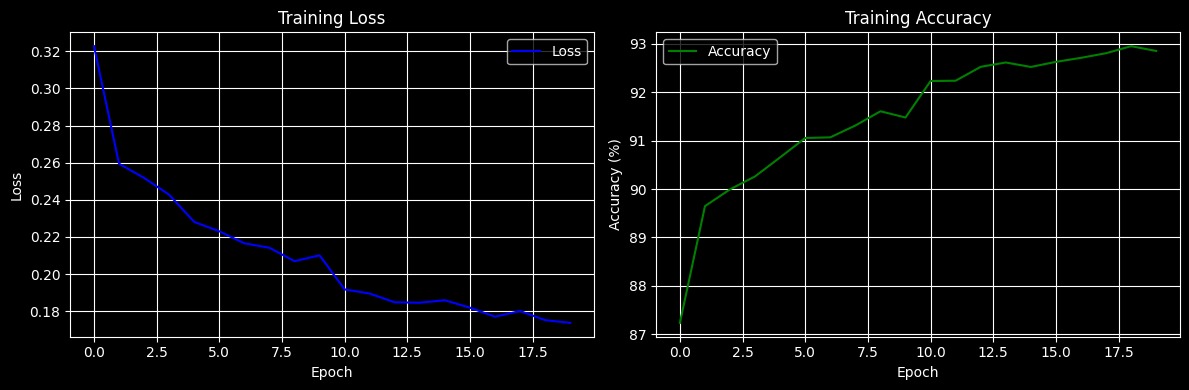

In [9]:
plot_curves(train_loss, train_acc)

## 测试

/tmp/ipykernel_1084/2940253780.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load('best_model.pth'))



测试集准确率: 93.59%
正确分类: 7032/7514


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
/tmp/ipykernel_1084/4218290519.py:10: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1084/4218290519.py:10: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()


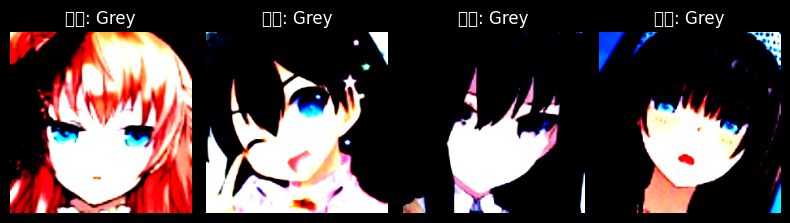

In [11]:
# 加载最佳模型
net.load_state_dict(torch.load('best_model.pth'))
net.eval()

total_correct = 0
total_samples = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        outputs = net(x)
        pred = outputs.argmax(dim=1)
        total_correct += pred.eq(y).sum().item()
        total_samples += y.size(0)

acc = total_correct / total_samples
print(f'\n测试集准确率: {acc*100:.2f}%')
print(f'正确分类: {total_correct}/{total_samples}')

# 显示预测结果
x, y = next(iter(test_loader))
x, y = x.to(device), y.to(device)
out = net(x)
pred = out.argmax(dim=1)
plot_image(x.cpu(), pred.cpu(), '预测')